I0000 00:00:1788672945.283694   23493 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788672945.369131   23493 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788672947.597948   23493 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1788672949.653264   23493 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1788672950.475096   23541 service.cc:153] XLA service 0x7f7d0401e1f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788672950.475123   23541 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step


I0000 00:00:1788672950.816802   23541 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


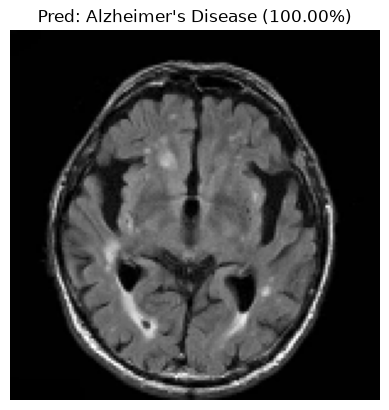

Predicted Label: Alzheimer's Disease
Confidence: 100.00%


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Define the class labels
class_labels = ["Alzheimer's Disease", "Cognitively Normal", 
                "Early Mild Cognitive Impairment (EMCI)", 
                "Late Mild Cognitive Impairment (LMCI)"]

model=tf.keras.models.load_model(r'Alzimer.keras')

# Specify the path to the image you want to load
img_path = r'alzheimerstest.png'  # Replace with the actual image path

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # Resize image to match the model's input size
img_array = image.img_to_array(img)  # Convert the image to a numpy array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (required for the model)
img_array = img_array / 255.0  # Normalize if your model was trained with normalized images

# Make a prediction using the model
predictions = model.predict(img_array)

# Get the predicted class and confidence
predicted_class = np.argmax(predictions[0])  # Get the index of the predicted class
confidence = np.max(predictions[0])  # Get the confidence (probability)

# Display the image with the true and predicted labels (you can replace the true class if needed)
# Since we're processing only one image, assume true class is unknown here for demonstration
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title(f"Pred: {class_labels[predicted_class]} ({confidence*100:.2f}%)")
plt.show()

# Print the predicted label and confidence in the console
print(f"Predicted Label: {class_labels[predicted_class]}")
print(f"Confidence: {confidence * 100:.2f}%")